# Rossmann Store Sales - Test Data Preprocessing Pipeline

This notebook applies the exact same preprocessing, imputation, and feature engineering steps developed in `k.ipynb` (for the training set) to the test set (`src/data/processed_data/test.csv`). This maintains strict feature compatibility and formatting between both datasets when fed into the models.

### Objectives:
1. Clean mixed-type values (e.g. `StateHoliday`).
2. Fill missing values using training-set statistics to avoid data leakage (e.g. `CompetitionDistance`, `CompetitionOpenMonths`).
3. Extract date/time features and build advanced engineered features (`CompetitionOpenMonths`, `Promo2ActiveMonths`, `IsPromo2Active`).
4. Encode categorical features exactly matching the training set's schema (including one-hot dummy alignment).
5. Transform numerical features using the `StandardScaler` fitted on the training set.
6. Save the final compatible dataset as `test1.csv`.

### 1. Imports

In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### 2. Load Train and Test Datasets
We load `train.csv` strictly to extract training-set statistics and fit the preprocessors (such as the standard scaler).

In [70]:
train_df = pd.read_csv("src/data/processed_data/train.csv", low_memory=False)
test_df = pd.read_csv("src/data/processed_data/test.csv", low_memory=False)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")

Train shape: (1017209, 18)
Test shape : (41088, 17)


In [71]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [72]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


### 3. Basic Test Set Inspection
Let's identify missing values in the test set.

In [73]:
print("Missing values in train set:")
miss = train_df.isnull().sum()
miss = miss[miss > 0]
for col, cnt in miss.items():
    print(f"  {col:<30} {cnt:>5,}  ({cnt/len(train_df)*100:.2f}%)")

Missing values in train set:
  CompetitionDistance            2,642  (0.26%)
  CompetitionOpenSinceMonth      323,348  (31.79%)
  CompetitionOpenSinceYear       323,348  (31.79%)
  Promo2SinceWeek                508,031  (49.94%)
  Promo2SinceYear                508,031  (49.94%)
  PromoInterval                  508,031  (49.94%)


In [74]:
print("Missing values in test set:")
miss = test_df.isnull().sum()
miss = miss[miss > 0]
for col, cnt in miss.items():
    print(f"  {col:<30} {cnt:>5,}  ({cnt/len(test_df)*100:.2f}%)")

Missing values in test set:
  Open                              11  (0.03%)
  CompetitionDistance               96  (0.23%)
  CompetitionOpenSinceMonth      15,216  (37.03%)
  CompetitionOpenSinceYear       15,216  (37.03%)
  Promo2SinceWeek                17,232  (41.94%)
  Promo2SinceYear                17,232  (41.94%)
  PromoInterval                  17,232  (41.94%)


### 4. Basic Data Cleaning & Imputation
- Convert `Date` to datetime format.
- Cast `StateHoliday` to string and replace `'0'` with `'none'` to handle mixed types.
- Impute missing `Open` rows (only 11 rows in the test set) with `1` (Open).

In [75]:
# Convert Date columns
train_df["Date"] = pd.to_datetime(train_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

train_df["Month"] = train_df["Date"].dt.month
train_df["Year"] = train_df["Date"].dt.year
train_df["WeekOfYear"] = train_df["Date"].dt.isocalendar().week.astype(int)

test_df["Month"] = test_df["Date"].dt.month
test_df["Year"] = test_df["Date"].dt.year
test_df["WeekOfYear"] = test_df["Date"].dt.isocalendar().week.astype(int)

# Clean StateHoliday
train_df["StateHoliday"] = train_df["StateHoliday"].astype(str).replace("0", "none")
test_df["StateHoliday"] = test_df["StateHoliday"].astype(str).replace("0", "none")



In [76]:
# Fill missing Open values in test set with 1 (Open)
test_df["Open"] = test_df["Open"].fillna(1)

In [77]:
zero_sales  = (train_df["Sales"] == 0).sum()
closed_rows = (train_df["Open"]  == 0).sum()
print(f"\n Zero-sales rows : {zero_sales:,}  ({zero_sales/len(train_df)*100:.1f}%)")
print(f"      Closed (Open=0) : {closed_rows:,} — will be DROPPED before modelling")
 


 Zero-sales rows : 172,871  (17.0%)
      Closed (Open=0) : 172,817 — will be DROPPED before modelling


In [78]:
train_df = train_df[(train_df["Open"] == 1) & (train_df["Sales"] > 0)]
len(train_df)

844338

In [79]:
# zero_sales  = (test_df["Sales"] == 0).sum()
closed_rows = (test_df["Open"]  == 0).sum()
print(f"      Closed (Open=0) : {closed_rows:,} — will be DROPPED before modelling")
 

      Closed (Open=0) : 5,984 — will be DROPPED before modelling


In [80]:
test_df = test_df[(test_df["Open"] == 1) ]
len(test_df)

35104

### 5. Filter Closed Training Rows & Drop Identifiers
We mimic the training pipeline by removing closed/zero-sales rows from the training set and dropping target-specific columns (like `Customers`). Note that we **do not** drop any rows from the test set.

In [81]:
# Save test set IDs for the final output
test_id = test_df["Id"].copy()
test_df = test_df.drop(columns=["Id"])


# Drop Open and Customers (Customers does not exist in test set)
train_df = train_df.drop(columns=["Open", "Customers"])
test_df = test_df.drop(columns=["Open"])

### 6. Extract Date Features & Impute Competition Statistics
- Extract `Month`, `Year`, and `WeekOfYear`.
- Impute missing `CompetitionDistance` using the training set maximum distance.
- Compute and impute `CompetitionOpenMonths`.

In [82]:
# # Extract time features
# for df in [train_df, test_df]:
#     df["Month"] = df["Date"].dt.month
#     df["Year"] = df["Date"].dt.year
#     df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

# Impute CompetitionDistance using training maximum
max_dist = train_df["CompetitionDistance"].max()
train_df["CompetitionDistance"] = train_df["CompetitionDistance"].fillna(max_dist)
test_df["CompetitionDistance"] = test_df["CompetitionDistance"].fillna(max_dist)

# Compute CompetitionOpenMonths
for df in [train_df, test_df]:
    df["CompetitionOpenMonths"] = (df["Year"] - df["CompetitionOpenSinceYear"]) * 12 + (df["Month"] - df["CompetitionOpenSinceMonth"])
    df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].clip(lower=0)

# Impute CompetitionOpenMonths using training maximum
max_comp_months = train_df["CompetitionOpenMonths"].max()
train_df["CompetitionOpenMonths"] = train_df["CompetitionOpenMonths"].fillna(max_comp_months)
test_df["CompetitionOpenMonths"] = test_df["CompetitionOpenMonths"].fillna(max_comp_months)

# Drop raw competition open columns
train_df = train_df.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"])
test_df = test_df.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"])

### 7. Promo Feature Engineering
- Compute `Promo2ActiveMonths` (clipped to 0).
- Compute binary flag `IsPromo2Active` indicating whether the current month falls inside the store's promo interval.

In [83]:
# Compute Promo2ActiveMonths
for df in [train_df, test_df]:
    df["Promo2ActiveMonths"] = np.where(
        df["Promo2"] == 1,
        (df["Year"] - df["Promo2SinceYear"]) * 12 + (df["WeekOfYear"] - df["Promo2SinceWeek"]) / 4.33,
        0
    )
    df["Promo2ActiveMonths"] = df["Promo2ActiveMonths"].clip(lower=0)

train_df = train_df.drop(columns=["Promo2SinceYear", "Promo2SinceWeek"])
test_df = test_df.drop(columns=["Promo2SinceYear", "Promo2SinceWeek"])

# Compute IsPromo2Active
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Aug": 8, "Sept": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

def is_promo2_active(row):
    if row["Promo2"] == 0 or pd.isna(row["PromoInterval"]):
        return 0
    active_months = [month_map[m.strip()] for m in row["PromoInterval"].split(",")]
    return int(row["Date"].month in active_months)

train_df["IsPromo2Active"] = train_df.apply(is_promo2_active, axis=1)
test_df["IsPromo2Active"] = test_df.apply(is_promo2_active, axis=1)

train_df = train_df.drop(columns=["PromoInterval"])
test_df = test_df.drop(columns=["PromoInterval"])

In [84]:
# Mean Sales for each Store
store_target_mean = train_df.groupby("Store")["Sales"].mean()

# Replace Store IDs with their mean Sales
train_df["Store_TE"] = train_df["Store"].map(store_target_mean)
test_df["Store_TE"] = test_df["Store"].map(store_target_mean)
train_df = train_df.drop(columns = ["Store"])
test_df = test_df.drop(columns = ["Store"])

### 8. Log Transforms, Encoding, & Dropping Date
- Log transform `Sales` (train set target), `CompetitionDistance`, and `Promo2ActiveMonths`.
- Apply cylindrical encoding (`sin`/`cos`) to `DayOfWeek`.
- Ordinally encode `Assortment`.
- One-hot encode `StoreType` and `StateHoliday`.

<Axes: xlabel='Store_TE', ylabel='Count'>

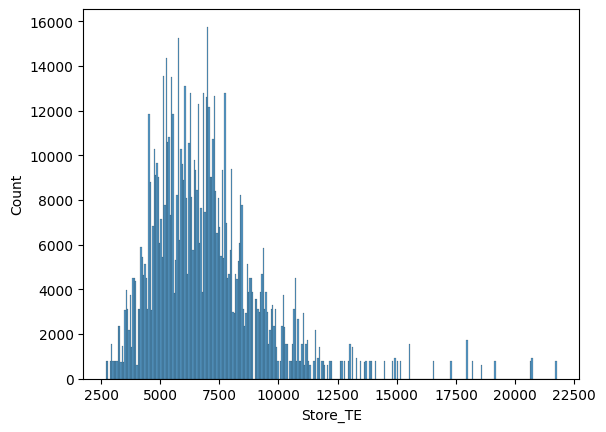

In [87]:
import seaborn as sns
sns.histplot(data = train_df, x="Store_TE")

In [88]:
# Log-transforms
train_df["Sales"] = np.log1p(train_df["Sales"])
train_df["Store_TE"] = np.log1p(train_df["Store_TE"])
test_df["Store_TE"] = np.log1p(test_df["Store_TE"])
train_df["CompetitionDistance"] = np.log1p(train_df["CompetitionDistance"])
test_df["CompetitionDistance"] = np.log1p(test_df["CompetitionDistance"])

train_df["Promo2ActiveMonths"] = np.log1p(train_df["Promo2ActiveMonths"])
test_df["Promo2ActiveMonths"] = np.log1p(test_df["Promo2ActiveMonths"])

# DayOfWeek - cylindrical encoding
for df in [train_df, test_df]:
    df["DayOfWeek_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["DayOfWeek_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)
train_df = train_df.drop(columns=["DayOfWeek"])
test_df = test_df.drop(columns=["DayOfWeek"])

# StoreType - one-hot
storetype_train = pd.get_dummies(train_df["StoreType"], prefix="StoreType", dtype=int)
storetype_test = pd.get_dummies(test_df["StoreType"], prefix="StoreType", dtype=int)
train_df = pd.concat([train_df, storetype_train], axis=1).drop(columns=["StoreType"])
test_df = pd.concat([test_df, storetype_test], axis=1).drop(columns=["StoreType"])

# Assortment - ordinal
assortment_order = {"a": 0, "b": 1, "c": 2}
train_df["Assortment_ord"] = train_df["Assortment"].map(assortment_order)
test_df["Assortment_ord"] = test_df["Assortment"].map(assortment_order)
train_df = train_df.drop(columns=["Assortment"])
test_df = test_df.drop(columns=["Assortment"])

# StateHoliday - one-hot
state_holiday_train = pd.get_dummies(train_df["StateHoliday"], prefix="Holiday", dtype=int)
state_holiday_test = pd.get_dummies(test_df["StateHoliday"], prefix="Holiday", dtype=int)
train_df = pd.concat([train_df, state_holiday_train], axis=1).drop(columns=["StateHoliday"])
test_df = pd.concat([test_df, state_holiday_test], axis=1).drop(columns=["StateHoliday"])

# Drop Date
train_df = train_df.drop(columns=["Date"])
test_df = test_df.drop(columns=["Date"])

### 9. Feature Alignment & Standard Scaling
- Align test features to match the exact training feature list.
- Fit the `StandardScaler` on the training set features (including `Sales`).
- Apply standard scaling to the test set using a temporary dummy `Sales` column to preserve dimension alignment, and then drop it.

In [90]:
# Align features
train_feature_cols = [c for c in train_df.columns if c != "Sales"]
for col in train_feature_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_feature_cols]

# Standard Scaling
num_cols = ["CompetitionDistance", "CompetitionOpenMonths", "Promo2ActiveMonths", "Sales", "Store_TE", "WeekOfYear", "Month", "Year"]
scaler = StandardScaler()

# Fit and transform on training data
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

# Scale test data using fitted scaler
test_df["Sales"] = 0.0  # Temporary dummy column
test_df = test_df[train_df.columns]  # Ensure order matches train_df exactly
test_df[num_cols] = scaler.transform(test_df[num_cols])

# Drop Sales from test features
test_df = test_df.drop(columns=["Sales"])
test_df = test_df[train_feature_cols]  # Align back to test features list

### 10. Re-insert ID Column & Save Preprocessed Test Data
We append the `Id` column at the beginning of the preprocessed dataframe and save the result to `src/data/processed_data/test1.csv`.

In [91]:
# Construct final test dataset with ID
test_final = test_df.copy()
test_final.insert(0, "Id", test_id)

print(f"Final preprocessed test set shape: {test_final.shape}")
print("Are any values null? ", test_final.isnull().any().any())

# Save dataset
test_final.to_csv("src/data/processed_data/test1.csv", index=False)
print("Preprocessed test dataset successfully saved as test1.csv")
test_final.head()

Final preprocessed test set shape: (35104, 23)
Are any values null?  False
Preprocessed test dataset successfully saved as test1.csv


,Id,Promo,SchoolHoliday,CompetitionDistance,Promo2,Month,Year,WeekOfYear,CompetitionOpenMonths,Promo2ActiveMonths,...,DayOfWeek_cos,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_ord,Holiday_a,Holiday_b,Holiday_c,Holiday_none
0,1,1,0,-0.322793,0,0.948937,1.502764,0.997438,-0.643706,-0.823754,...,-0.900969,0,0,1,0,0,0,0,0,1
1,2,1,0,1.212412,1,0.948937,1.502764,0.997438,-0.609815,1.567435,...,-0.900969,1,0,0,0,0,0,0,0,1
2,3,1,0,1.550055,0,0.948937,1.502764,0.997438,-0.732467,-0.823754,...,-0.900969,1,0,0,0,2,0,0,0,1
3,4,1,0,0.810426,0,0.948937,1.502764,0.997438,-0.761516,-0.823754,...,-0.900969,1,0,0,0,0,0,0,0,1
4,5,1,0,-0.024031,0,0.948937,1.502764,0.997438,-0.487164,-0.823754,...,-0.900969,1,0,0,0,2,0,0,0,1


In [92]:
train_final = train_df.copy()
train_final.to_csv("src/data/processed_data/train1.csv", index=False)
print("Preprocessed test dataset successfully saved as train1.csv")
train_final.head()

Preprocessed test dataset successfully saved as train1.csv


,Sales,Promo,SchoolHoliday,CompetitionDistance,Promo2,Month,Year,WeekOfYear,CompetitionOpenMonths,Promo2ActiveMonths,...,DayOfWeek_cos,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_ord,Holiday_a,Holiday_b,Holiday_c,Holiday_none
0,-0.444708,1,1,-0.322793,0,0.347245,1.502764,0.510986,-0.646934,-0.823754,...,-0.222521,0,0,1,0,0,0,0,0,1
1,-0.111587,1,1,-0.832816,1,0.347245,1.502764,0.510986,-0.630795,1.673760,...,-0.222521,1,0,0,0,0,0,0,0,1
2,0.630477,1,1,1.212412,1,0.347245,1.502764,0.510986,-0.613043,1.549444,...,-0.222521,1,0,0,0,0,0,0,0,1
3,1.855099,1,1,-0.779312,0,0.347245,1.502764,0.510986,-0.666300,-0.823754,...,-0.222521,0,0,1,0,2,0,0,0,1
4,-0.650481,1,1,1.690365,0,0.347245,1.502764,0.510986,-0.774427,-0.823754,...,-0.222521,1,0,0,0,0,0,0,0,1
